In [2]:
class Position:
    def __init__(self,x,y):
        if not isinstance(x,int) or not isinstance(y,int):
            raise TypeError("x and y must be integer")
        if x<0 or y<0:
            raise ValueError("x and y must be greater or equal to zero")
        self.x=x
        self.y=y
    def distance_to(self,other):
        if not isinstance(other,Position):
            raise TypeError("other no available")
        return abs(self.x-other.x) + abs(self.y-other.y)

    def __str__(self):
        return f"({self.x},{self.y})"

p1=Position(2,3)
p2=Position(3,4)
print(p1.distance_to(p2))
print(p1)

    

2
(2,3)


In [3]:
class DeliveryTask:
    def __init__(self,task_id,pickup,drop):
        if not isinstance(task_id , int):
            raise TypeError("task id must be integer")
        if task_id<=0:
            raise ValueError("task id must be positive")
        if not isinstance(pickup,Position):
            raise TypeError("pickup position not available")
        if not isinstance(drop,Position):
            raise TypeError("drop position not available")
    
        self.task_id=task_id
        self.pickup=pickup
        self.drop=drop
        self.status = "pending" 

    def update_status(self,new_status):
        if not isinstance(new_status,str):
            raise TypeError("new status must be string")
        allowed_status=["pending","picked","completed"]
        if not new_status in allowed_status:
            raise ValueError("new status not available")
        if self.status=="pending":
            if new_status!="picked":
                raise ValueError("invalid status")
            
        elif self.status=="picked":
            if new_status!="completed":
                raise ValueError("invalid status") 
            
        elif self.status=="completed":
            raise ValueError("Completed task cannot be changed")      

        self.status=new_status    

    def __str__(self):
        return f"Task_ID:{self.task_id} | Status:{self.status} | pickup:{self.pickup} | drop:{self.drop}"
p1=Position(2,3)
p2=Position(5,6)
d=DeliveryTask(123,p1,p2)
print(d)


Task_ID:123 | Status:pending | pickup:(2,3) | drop:(5,6)


In [4]:
class Robot:
    def __init__(self,name,position):
        if not isinstance(name,str):
            raise TypeError("name must be string")
        if not name:
            raise ValueError("name can not be empty")
    
        if not isinstance(position,Position):
            raise TypeError("Position not available")
        self.name=name
        self.position=position
        self.task_queue=[]
        self.current_task=None
        self.battery=100
        self.position_history=[]
        self.battery_history=[]
        self.all_tasks=[]

    def assign_task(self,task):
        if not isinstance(task,DeliveryTask):
            raise TypeError("task not available")
        
        if task.status!="pending":
            raise ValueError("Task must be pending")        
        
        self.task_queue.append(task)
        self.all_tasks.append(task)
        

    def move_step(self,target):
        if not isinstance(target,Position):
            raise TypeError("Target not available")
        if self.battery==0:
            return self.position
        
        old_x=self.position.x
        old_y=self.position.y
        if self.position.x!=target.x:
            if self.position.x>target.x: 
                self.position.x-=1
            elif self.position.x<target.x:  
                self.position.x+=1
        elif self.position.y!=target.y:        
            if self.position.y>target.y:
                self.position.y-=1
            elif self.position.y<target.y:  
                self.position.y+=1
        if old_x!=self.position.x or old_y!=self.position.y:
            self.battery-=1
            self.position_history.append((self.position.x,self.position.y))
            self.battery_history.append(self.battery)
                
        return self.position
    
    def process(self):
        if self.battery==0:
            return
        if self.current_task is None:
            if self.task_queue:
                self.current_task=self.task_queue.pop(0)
            if self.current_task is None:
                return
            
        if self.current_task.status=="pending":
            if self.position.x!=self.current_task.pickup.x or self.position.y!=self.current_task.pickup.y:
                self.move_step(self.current_task.pickup)
            else:
                self.current_task.update_status("picked")
        elif self.current_task.status=="picked":
            if self.position.x!=self.current_task.drop.x or self.position.y!=self.current_task.drop.y:
                self.move_step(self.current_task.drop)
            else:
                self.current_task.update_status("completed") 
        elif self.current_task.status=="completed":
            self.current_task=None                 
    
    def __str__(self):
        if self.current_task is None:
            task_info="None"
        else:
           task_info=f"Task:{self.current_task.task_id} | status:{self.current_task.status}"    
        
        return f"Robot:{self.name} |  Position:{self.position} |{task_info} | Battery:{self.battery}"                
r=Robot("R1",Position(1,1))
target=Position(5,6)
p1=Position(2,3)
p2=Position(4,4)
task1=DeliveryTask(123,p1,p2)
p1=Position(4,5)
p2=Position(8,9)
task2=DeliveryTask(234,p1,p2)
r.assign_task(task1)
r.assign_task(task2)
for _ in range(20):
    r.process()
    print(r)
print("Position_history:",r.position_history)
print("battery_hostory:",r.battery_history)


Robot:R1 |  Position:(2,1) |Task:123 | status:pending | Battery:99
Robot:R1 |  Position:(2,2) |Task:123 | status:pending | Battery:98
Robot:R1 |  Position:(2,3) |Task:123 | status:pending | Battery:97
Robot:R1 |  Position:(2,3) |Task:123 | status:picked | Battery:97
Robot:R1 |  Position:(3,3) |Task:123 | status:picked | Battery:96
Robot:R1 |  Position:(4,3) |Task:123 | status:picked | Battery:95
Robot:R1 |  Position:(4,4) |Task:123 | status:picked | Battery:94
Robot:R1 |  Position:(4,4) |Task:123 | status:completed | Battery:94
Robot:R1 |  Position:(4,4) |None | Battery:94
Robot:R1 |  Position:(4,5) |Task:234 | status:pending | Battery:93
Robot:R1 |  Position:(4,5) |Task:234 | status:picked | Battery:93
Robot:R1 |  Position:(5,5) |Task:234 | status:picked | Battery:92
Robot:R1 |  Position:(6,5) |Task:234 | status:picked | Battery:91
Robot:R1 |  Position:(7,5) |Task:234 | status:picked | Battery:90
Robot:R1 |  Position:(8,5) |Task:234 | status:picked | Battery:89
Robot:R1 |  Position:(8

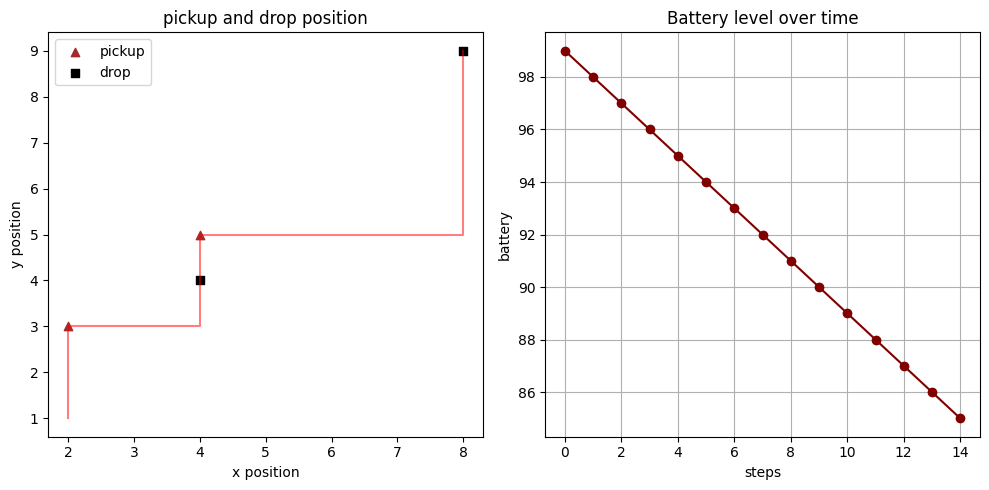

In [5]:
def visualize(robot):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,5))
    x_val=[p[0] for p in robot.position_history] 
    y_val=[p[1] for p in robot.position_history]
    plt.subplot(1,2,1)
    #plt.scatter(x_val,y_val,color="green",s=50,)
    plt.plot(x_val,y_val,color="red",alpha=0.5)
    plt.title("Robot Movement Path")
    plt.xlabel("x_values") 
    plt.ylabel("y_values")
    plt.grid()

    for i, task in enumerate(robot.all_tasks):
        plt.scatter(task.pickup.x,task.pickup.y,color="brown",marker="^",label="pickup" if i==0 else "") 
        plt.scatter(task.drop.x,task.drop.y,color="black",marker="s",label="drop" if i==0 else "")

    plt.title("pickup and drop position")
    plt.xlabel("x position")
    plt.ylabel("y position")

    plt.legend()
    plt.grid()
    

    plt.subplot(1,2,2)
    steps=list(range(len(robot.battery_history)))
    battery_value=robot.battery_history
    plt.plot(steps,battery_value,color="maroon",marker="o")
    plt.title("Battery level over time")
    plt.xlabel("steps")
    plt.ylabel("battery")
    plt.grid()

    plt.tight_layout()
    plt.show()

visualize(r)